<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 

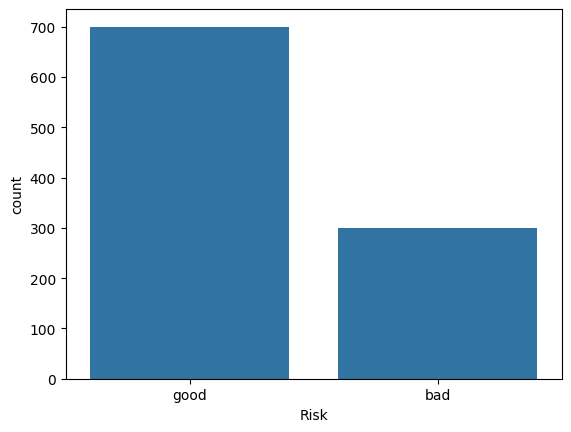

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Age                          1000 non-null   int64
 1   Job                          1000 non-null   int64
 2   Credit amount                1000 non-null   int64
 3   Duration                     1000 non-null   int64
 4   Risk                         1000 non-null   int64
 5   Sex_male                     1000 non-null   bool 
 6   Housing_own                  1000 non-null   bool 
 7   Housing_rent                 1000 non-null   bool 
 8   Saving accounts_moderate     1000 non-null   bool 
 9   Saving accounts_quite rich   1000 non-null   bool 
 10  Saving accounts_rich         1000 non-null   bool 
 11  Saving accounts_unknown      1000 non-null   bool 
 12  Checking account_moderate    1000 non-null   bool 
 13  Checking account_rich        1000 non-null   bool

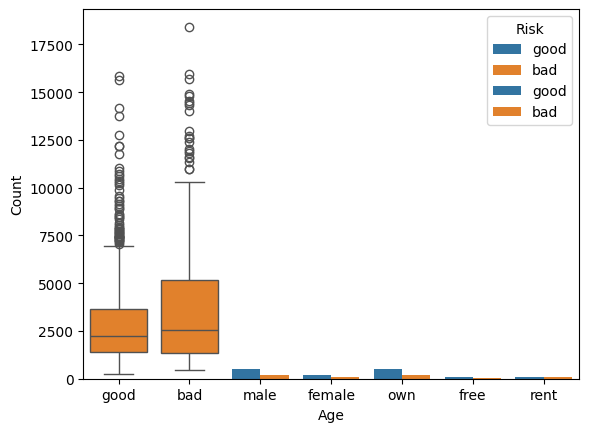

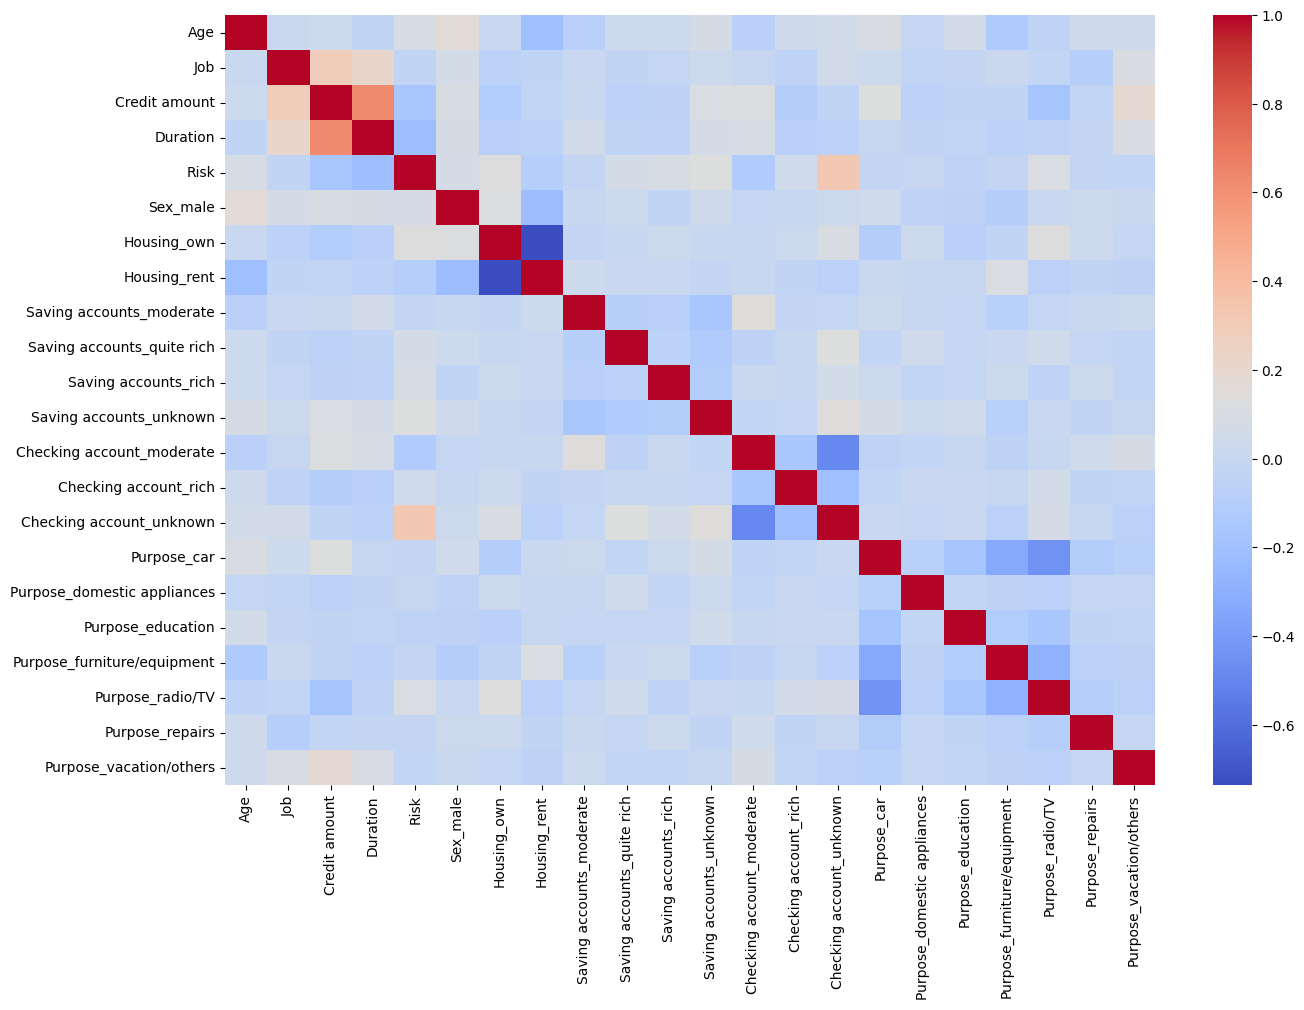

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
# 1. Data collection
df=pd.read_excel("german_credit_data.xlsx")
# 2. Data understanding (knowing data)
df.info()
df.head(5)
df.describe()
df.isnull().sum()
df.isna().sum()
# 3. Data cleaning(filling null values)
df['Saving accounts'].value_counts()
df['Saving accounts']=df['Saving accounts'].fillna("unknown")
df["Checking account"].value_counts()
df["Checking account"]=df["Checking account"].fillna("unknown")
df['Saving accounts'].value_counts()
df.info()
# 4. Data preprocessing (Encoding)
df["Risk"].value_counts()
sns.countplot(x="Risk", data=df)
plt.show()
sns.histplot(df["Age"])
sns.boxplot(x="Risk", y="Credit amount", data=df)
sns.countplot(x="Sex", hue="Risk", data=df)
sns.countplot(x="Housing", hue="Risk", data=df)
df=pd.get_dummies(df,columns=['Sex','Housing','Saving accounts','Checking account','Purpose'],drop_first=True)
df["Risk"] = df["Risk"].map({
    "good":1,
    "bad":0
})
df.info()
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
# feature selection
X = df.drop("Risk", axis=1)
y = df["Risk"]
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y
)

# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#model selection
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
#Prediction
y_pred = model.predict(X_test)
#Evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,classification_report,roc_auc_score
accuracy_score_calculate=accuracy_score(y_test,y_pred)
confusion_matrix_calculate=confusion_matrix(y_test,y_pred)
classification_report_calculate=classification_report(y_test,y_pred)
f1_score_calculate=f1_score(y_test,y_pred)
print(f"accuracy_score{accuracy_score_calculate}")
print(f"confusion_matrix{confusion_matrix_calculate}")
print(f"classification_report{classification_report_calculate}")
print(f"f1_score{f1_score_calculate}")

# SVM model prediction
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred)) 